# NGC 5010: Adam + L-BFGS on Real GECKOS/MUSE Maps

Same workflow as `optimization_pipeline2_NGC3630.ipynb`, applied to **NGC 5010**. The observed maps are the nGIST-reduced GECKOS/MUSE kinematics loaded by `geckos_data.load_geckos_maps`; the fit is kinematic (`v_rot`, `sigma`), and it is run **at a constant smoothing bandwidth** — no coarse-to-fine annealing (see "Why no annealing" below) — in two optimizer stages: **Adam** first, then an **L-BFGS** polish.

## How NGC 5010 differs from NGC 3630

The two galaxies need different settings, and the data itself says why:

| measured on the loaded maps | NGC 5010 | NGC 3630 |
|---|---|---|
| x-coverage | **symmetric**, -6.8 to +6.8 kpc | -1.4 to +5.8 kpc (63% off-centre) |
| central vs outer dispersion (r<1 kpc / r>2.5 kpc) | **1.23** | 1.74 |
| peak sigma | 112 km/s | 167 km/s |
| rotation | -180 to +183 km/s | -173 to +146 km/s |

Consequently:

- **`center_percentile=None`.** The pointing is well centred, so the global flux-weighted centroid is the right centre. (NGC 3630 needed centring on the nucleus because its offset pointing dragged the centroid toward the covered side.)
- **`spheroid_corotation=1.0`.** With only a 1.23 central dispersion enhancement this galaxy is rotation-dominated, not hosting a strongly dispersion-supported core, so the spheroid is modelled as co-rotating with the disk. (NGC 3630, with a 1.74 ratio and a sharp sigma peak, used 0.5 — a pressure-supported bulge.)
- **`L0` bounded (2, 8)** rather than (2, 5), and a larger field: `extent = 7 x 4` kpc.

Everything else follows `fit_geckos.py` and the NGC 3630 notebook: `loss_weights = (0, 2, 3, 0)` — the MUSE FLUX is *light* not mass (its normalization is fiducial and its sharp nucleus is not reproducible by a 3-component model), and the Poisson self-consistency term is off because a real galaxy cannot be pre-made self-consistent the way the mock could. The disk dispersion is capped so any central sigma excess must come from the bulge, and a mild Tikhonov prior anchors the parameters the kinematics leave degenerate.

**There is no ground truth**, so nothing here is scoreable: the fitted values are an answer, not a score. Without a second optimization path to compare against, the only remaining diagnostics are the zero-gradient probe (Section 2), bound proximity, and how far each parameter moved from its initial guess.

## The two-stage optimizer

Adam is a first-order method: it rescales the gradient per coordinate but still takes a fixed-size step along a direction that ignores curvature. That is the right trade far from the solution, where the gradients are noisy and badly scaled. It is the wrong trade at the end, on a loss whose parameters differ in sensitivity by orders of magnitude — the fit ends up crawling along a narrow valley floor, and 600 Adam steps do not mean 600 steps' worth of convergence.

L-BFGS builds a low-rank inverse-Hessian estimate from the last few (step, gradient-change) pairs and gets its step length from a Wolfe line search, which is exactly what a narrow valley needs. It runs second, at the same fixed bandwidth, on the identical objective.

This notebook also carries two configuration changes made after inspecting an earlier fit's residuals -- a weaker prior and a re-weighted loss. Section 2 documents what was measured and what each change does and does not fix.

**This galaxy is a favourable case for the L-BFGS stage.** The two things that usually make a second-order method inapplicable here are absent: there is no annealing (a changing objective would invalidate the curvature memory — see below), and the Tikhonov prior (`reg_weight = 0.05`) adds a strictly convex quadratic in log-space that lifts the flattest directions off zero. What it cannot do is add information — see the caveats at the end.


In [1]:
import os
import sys
import copy
import math
import numpy as np
import jax
import jax.numpy as jnp
import optax
from jax.flatten_util import ravel_pytree
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

sys.path.insert(0, os.path.abspath('.'))
from geckos_data import load_geckos_maps

from phoenix.actions_to_phasespace.actions_to_phasespace_nn import PhoenixMapper
from phoenix.optimization.pipeline import (
    fit, make_loss_fn, params_to_log, log_to_params, log_bounds_tree,
    DEFAULT_PARAM_BOUNDS,
)
from phoenix.optimization.observables import render_maps_batched

/home/annalena/phoenix/phoenix/distribution_functions/disk.py:14: UserWarning: As of jaxtyping version 0.2.24, jaxtyping now prefers the syntax
```
from jaxtyping import jaxtyped
# Use your favourite typechecker: usually one of the two lines below.
from typeguard import typechecked as typechecker
from beartype import beartype as typechecker

@jaxtyped(typechecker=typechecker)
def foo(...):
```
and the old double-decorator syntax
```
@jaxtyped
@typechecker
def foo(...):
```
should no longer be used. (It will continue to work as it did before, but the new approach will produce more readable error messages.)
In particular note that `typechecker` must be passed via keyword argument; the following is not valid:
```
@jaxtyped(typechecker)
def foo(...):
```

  @jaxtyped
/home/annalena/phoenix/phoenix/distribution_functions/disk.py:21: UserWarning: As of jaxtyping version 0.2.24, jaxtyping now prefers the syntax
```
from jaxtyping import jaxtyped
# Use your favourite typechecker: usually one o

## 1. The Observed Galaxy

Distance and stellar mass from the GECKOS master catalogue, as in `fit_geckos.py`:
`kpc/arcsec = D[Mpc]*1e3/206265`, `Mstar = 10**lmstar`.

In [2]:
NAME = 'NGC5010'
STEM = 'NGC5010_iDR2.0_1_SN100_5_MW_4800-8900'
DATADIR = os.path.join('data', '7_NGC5010', 'maps', STEM)

D_MPC = 42.2               # GECKOS master catalogue
LMSTAR = 10.6833
KPC_PER_ARCSEC = D_MPC * 1e3 / 206265.0
MSTAR = 10.0 ** LMSTAR

EXTENT_X, EXTENT_Z = 7.0, 4.0
GRID_SIZE = 40
CENTER_PERCENTILE = None    # well-centred pointing -> global flux centroid is correct
SPHEROID_COROTATION = 1.0   # rotation-dominated, no strongly hot core

obs_maps, info = load_geckos_maps(
    os.path.join(DATADIR, f'{STEM}_kin_maps.fits'),
    os.path.join(DATADIR, f'{STEM}_spatial_binning_maps.fits'),
    kpc_per_arcsec=KPC_PER_ARCSEC, extent_x=EXTENT_X, extent_z=EXTENT_Z,
    grid_size=GRID_SIZE, Mstar_fiducial=MSTAR, center_percentile=CENTER_PERCENTILE,
)

data_mask = np.array(obs_maps['mass']) > 0
vmax_mass = float(np.nanmax(np.array(obs_maps['mass'])))

print(f"{NAME}:  D = {D_MPC} Mpc -> {KPC_PER_ARCSEC:.4f} kpc/arcsec,  logM* = {LMSTAR}")
print(f"  PA = {info['position_angle_deg']:.1f} deg,  v_sys = {info['v_systemic_kms']:.1f} km/s")
print(f"  filled cells: {int(data_mask.sum())}/{GRID_SIZE**2} ({info['filled_fraction']*100:.0f}%)")
v, s = np.array(obs_maps['v_rot']), np.array(obs_maps['sigma'])
print(f"  v_rot in [{v[data_mask].min():.0f}, {v[data_mask].max():.0f}] km/s")
print(f"  sigma in [{s[data_mask].min():.0f}, {s[data_mask].max():.0f}] km/s")

# Quantify the two properties that set the modelling choices above.
_xc = 0.5 * (np.linspace(-EXTENT_X, EXTENT_X, GRID_SIZE + 1)[:-1]
             + np.linspace(-EXTENT_X, EXTENT_X, GRID_SIZE + 1)[1:])
_zc = 0.5 * (np.linspace(-EXTENT_Z, EXTENT_Z, GRID_SIZE + 1)[:-1]
             + np.linspace(-EXTENT_Z, EXTENT_Z, GRID_SIZE + 1)[1:])
_X, _Z = np.meshgrid(_xc, _zc)
_r = np.hypot(_X, _Z)
core, outer = (_r < 1.0) & data_mask, (_r > 2.5) & data_mask
print(f"  x-coverage [{_X[data_mask].min():+.1f}, {_X[data_mask].max():+.1f}] kpc "
      f"-> {abs(_X[data_mask].min() + _X[data_mask].max()) / np.ptp(_X[data_mask]) * 100:.0f}% off-centre")
print(f"  sigma core(r<1) = {s[core].mean():.0f} km/s,  outer(r>2.5) = {s[outer].mean():.0f} km/s"
      f"  -> ratio {s[core].mean() / s[outer].mean():.2f}")

NGC5010:  D = 42.2 Mpc -> 0.2046 kpc/arcsec,  logM* = 10.6833
  PA = 30.9 deg,  v_sys = 1.2 km/s
  filled cells: 558/1600 (35%)
  v_rot in [-180, 183] km/s
  sigma in [40, 112] km/s
  x-coverage [-6.8, +6.8] kpc -> 0% off-centre
  sigma core(r<1) = 78 km/s,  outer(r>2.5) = 64 km/s  -> ratio 1.23


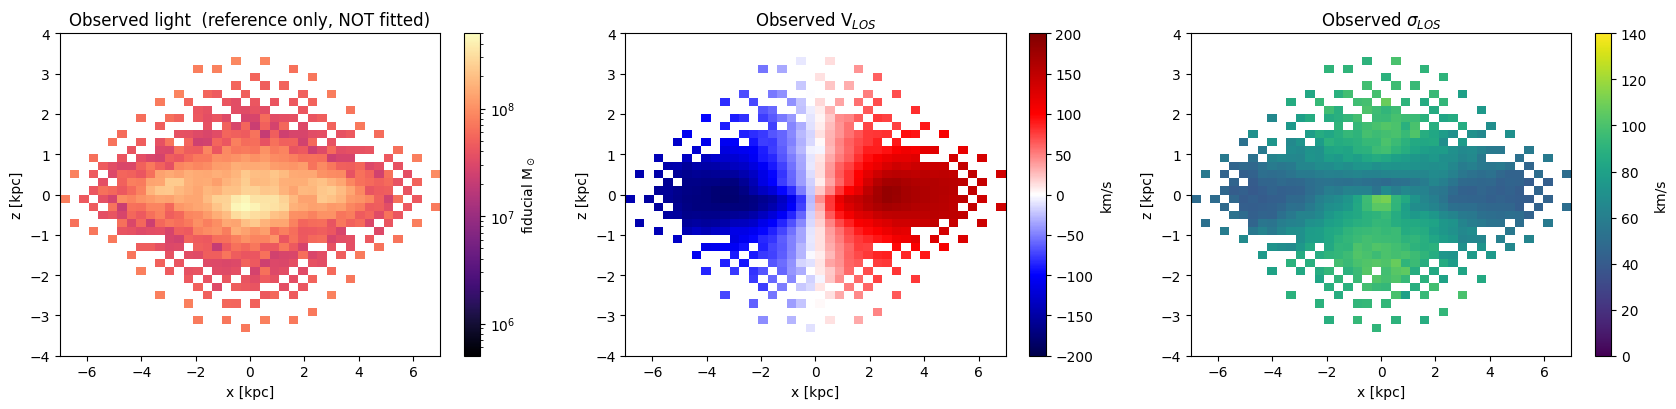

In [3]:
EXTENT = [-EXTENT_X, EXTENT_X, -EXTENT_Z, EXTENT_Z]
SIGMA_VMAX = 140.0     # NGC 5010 peaks near 112 km/s

def masked(a):
    return np.where(data_mask, np.array(a), np.nan)

fig, axes = plt.subplots(1, 3, figsize=(17, 4.2))
im = axes[0].imshow(masked(obs_maps['mass']), origin='lower', extent=EXTENT, cmap='magma',
                    norm=LogNorm(vmin=vmax_mass / 1e3, vmax=vmax_mass), aspect='auto')
axes[0].set_title('Observed light  (reference only, NOT fitted)')
fig.colorbar(im, ax=axes[0], label='fiducial M$_\\odot$')
im = axes[1].imshow(masked(obs_maps['v_rot']), origin='lower', extent=EXTENT,
                    cmap='seismic', vmin=-200, vmax=200, aspect='auto')
axes[1].set_title('Observed V$_{LOS}$'); fig.colorbar(im, ax=axes[1], label='km/s')
im = axes[2].imshow(masked(obs_maps['sigma']), origin='lower', extent=EXTENT,
                    cmap='viridis', vmin=0, vmax=SIGMA_VMAX, aspect='auto')
axes[2].set_title('Observed $\\sigma_{LOS}$'); fig.colorbar(im, ax=axes[2], label='km/s')
for ax in axes:
    ax.set_xlabel('x [kpc]'); ax.set_ylabel('z [kpc]')
plt.tight_layout(); plt.show()

## 2. Fit Configuration

As in the NGC 3630 notebook, `OBS_BANDWIDTH` is a **modelling choice**, not a measured PSF: the data's effective resolution comes from seeing (~0.8" ~ 0.16 kpc at 42 Mpc), the Voronoi binning, and the 0.35 kpc grid cell. 0.4 kpc is the resolution the observation is treated as having, and **both** optimizer stages run at that bandwidth: Adam via `anneal_bandwidth=(0.4, 0.4)` (constant), then L-BFGS at `soft_bin_h=0.4`. Because the schedule never moves, the two stages descend the identical objective and their losses are directly comparable.


### Why these two settings changed

An earlier run of this fit (`NGC5010_fit_results.json`, `LOSS_WEIGHTS = (0, 2, 3, 0)`, `REG_WEIGHT = 0.05`) reproduced the observed `V_LOS` map with the **disk too weak**: an antisymmetric residual of +-30-35 km/s confined to |z| < 1 kpc at |x| = 1.5-4 kpc, i.e. the model under-rotating exactly where the thin disk should dominate. Decomposing that model into its disk and spheroid tracers says why, and rules out the obvious explanation:

| measured on the previous fit | value |
|---|---|
| spheroid share of the midplane light at \|x\| = 1.5-4 kpc | **3-5%** |
| disk-only `v_rot` vs total `v_rot` at x = 2.6 kpc | 148.3 vs 144.8 km/s |
| model vs observed `sigma`, midplane | **82-85 vs 60-62 km/s** |
| observed `v_rot` vs model at x = 2.6 kpc | **181 vs 145 km/s** |
| data gradient of the bulge DF shape parameters | **2e-7 to 9e-6** (disk/potential: ~1e-3) |
| bulge DF parameters' distance from their initial guess after 600 steps | **< 0.3%** |

The spheroid is not diluting the rotation — it contributes almost nothing in the plane, and deleting it would change the map hardly at all. The **disk itself** is rotating too slowly, because it is too hot: a disk with that much dispersion carries a large asymmetric drift, which pulls the mean `v_phi` below `v_circ`. The `sigma` excess and the `v_rot` deficit are one defect, not two.

The fit heated the disk because nothing else could carry the off-plane dispersion. The spheroid supplies only ~4% of the midplane light and does not reach half the light until |z| ~ 1.8 kpc, and its DF shape parameters are effectively invisible to these maps (gradients three to four orders of magnitude below everything else), so the prior held them at their initial values for the whole run.

**The two changes:**

- **`REG_WEIGHT` 0.05 -> 0.01.** Measured at the previous fit's own parameters, the Tikhonov prior's restoring pull was the *same order as the data gradient for 15 of 21 parameters*. That is not a mild regularizer holding the degenerate directions — it was carrying about half the objective, including for `M_bulge`, `a_bulge`, `a_halo` and `b_disk`, the parameters that set how centrally concentrated the mass is. Weakening it lets the data choose the mass distribution. It is also the change most likely to have a side effect: parameters with ~1e-6 gradients are now much freer to drift toward their bounds, so the probe cell below prints an explicit warning listing them, and the `AT BOUND` flags in Section 7 are the check.
- **`LOSS_WEIGHTS` (0, 2, 3, 0) -> (0, 3, 2, 0).** Be clear about what this one is: it is **tuning the objective**, not fixing a defect. Rotation and dispersion are coupled through the asymmetric drift, so the previous weighting — `sigma` favoured 3:2 — actively bought dispersion fidelity with rotation fidelity. Reversing it buys the opposite. It will make the disk more prominent, and it will make the `sigma` residual worse; that trade is a choice about which observable this fit is meant to reproduce, and no result here should be read as evidence that the reversed weighting is the *correct* one.

**What neither change fixes.** The model's rotation curve rises monotonically to ~168 km/s at 4.7 kpc while the observed one peaks near 181 km/s at 2.6 kpc and falls to 148 km/s by 5.8 kpc. Reproducing a curve that *declines* inside 6 kpc needs more central mass concentration than this three-component model reached; a weaker prior gives it more room to try, but if the residual keeps its shape at large \|x\| that is a model-structure limitation, not a tuning one. A cold thin disk plus a hot, vertically extended component is also not something this DF family can build independently, since the spheroid's shape is unconstrained by these maps.


### Why no annealing

Bandwidth annealing exists to cure the vanishing gradient of the masked log-*mass* term when the model and data maps do not overlap. Here `w_mass = 0`, so that failure mode never arises, while the wide-bandwidth stages blur away the rotation dipole and the central sigma structure the loss actually depends on. On NGC 3630 the constant-bandwidth run already won on both counts (final loss 0.0632 vs 0.0779; `v_rot` residual RMS 21.2 vs 24.4 km/s).

There is also a problem intrinsic to blurring *real* data with partial coverage. Evaluated at fixed parameters, the annealed loss varies ~5x with bandwidth (0.194 at h=4, peaking 0.277 at h=2, down to 0.056 at h=0.4) for two reasons: the observation is not a Gaussian KDE at `obs_bandwidth` (it is flux summed into cells, so blurring it does not reproduce what the model's KDE at h produces), and the footprint has a hard edge which blurring smears into a soft one that the model — which extends beyond the observed region — cannot match. So the intermediate objectives an annealed run optimizes are distorted, and it buys nothing on kinematic maps.

The constant-bandwidth run compares like with like at every step and is unaffected by any of this.

This also happens to be what makes the L-BFGS stage possible at all. A quasi-Newton method accumulates curvature information across iterations, which is only meaningful if the objective is fixed; an annealed run changes the objective at every step and would invalidate the memory continuously. A galaxy where annealing is the wrong choice anyway is therefore the natural place to use one.


In [4]:
N_PARTICLES = 20_000       # fit_geckos.py uses 35_000 for production; reduced here for runtime
N_PARTICLES_RENDER = 100_000
N_STEPS = 600
SEED = 0
LEARNING_RATE = 0.05
OBS_BANDWIDTH = 0.4
# (mass, v_rot, sigma, poisson): kinematic-only. v_rot is now weighted ABOVE sigma
# (was 2/3, now 3/2) -- see "Why these two settings changed" above.
LOSS_WEIGHTS = (0.0, 3.0, 2.0, 0.0)
REG_WEIGHT = 0.01                       # was 0.05; the prior was carrying half the objective

init_pot = {'M_halo': 8e11, 'a_halo': 15.0, 'M_disk': 4e10, 'a_disk': 2.0,
            'b_disk': 0.2, 'M_bulge': 5e9, 'a_bulge': 0.5}
init_disk = {'R0': 4.0, 'Rd': 1.5, 'Sigma0': 1000.0, 'RsigR': 5.0, 'RsigZ': 5.0,
             'sigmaR0_R0': 60.0, 'sigmaz0_R0': 40.0, 'L0': 3.0, 'Rinit_for_Rc': 4.0}
init_bulge = {'N0_spheroid': 5e9, 'J0_spheroid': 60.0, 'Gamma_spheroid': 1.5,
              'Beta_spheroid': 4.5, 'eta_spheroid': 1.0}

param_bounds = copy.deepcopy(DEFAULT_PARAM_BOUNDS)
param_bounds['disk']['L0'] = (2.0, 8.0)             # NGC 5010: (2, 8), cf. (2, 5) for NGC 3630
param_bounds['disk']['sigmaR0_R0'] = (5.0, 120.0)   # cap the disk so any central sigma
param_bounds['disk']['sigmaz0_R0'] = (5.0, 90.0)    #   excess must come from the bulge

FIT_KW = dict(
    N_disk=N_PARTICLES, N_bulge=N_PARTICLES, grid_size=GRID_SIZE,
    extent_x=EXTENT_X, extent_z=EXTENT_Z, prng_seed=SEED,
    loss_weights=LOSS_WEIGHTS, poisson_kwargs={},
    learning_rate=LEARNING_RATE, n_steps=N_STEPS,
    spheroid_corotation=SPHEROID_COROTATION, param_bounds=param_bounds,
    obs_bandwidth=OBS_BANDWIDTH, reg_weight=REG_WEIGHT,
)

mapper = PhoenixMapper()

Loading Phoenix Surrogate Model...
 -> Weights: /home/annalena/phoenix/phoenix/torus_mapping_neural_network/phoenix_weights.msgpack
 -> Stats:   /home/annalena/phoenix/phoenix/torus_mapping_neural_network/phoenix_norm_stats.npz
Model loaded and ready for inference!


### Which parameters can this dataset constrain?

Measured, not assumed. `Sigma0` and `N0_spheroid` are degenerate for *any* dataset (the tracer weights are renormalized, so an overall DF amplitude cancels exactly); others may be degenerate for this particular loss. Anything with a numerically zero gradient can only drift, so it is frozen.

In [5]:
probe_loss = make_loss_fn(
    mapper, obs_maps,
    N_disk=N_PARTICLES, N_bulge=N_PARTICLES, grid_size=GRID_SIZE,
    extent_x=EXTENT_X, extent_z=EXTENT_Z, prng_seed=SEED,
    loss_weights=LOSS_WEIGHTS, poisson_kwargs={},
    spheroid_corotation=SPHEROID_COROTATION, obs_bandwidth=OBS_BANDWIDTH,
)
(_l, _a), grads = jax.value_and_grad(probe_loss, has_aux=True)(
    params_to_log(init_pot, init_disk, init_bulge), OBS_BANDWIDTH)

print("|d loss / d log(param)| at the initial guess:")
flat = [(abs(float(g)), grp, k) for grp in ('pot', 'disk', 'bulge')
        for k, g in grads[grp].items()]
# Threshold raised from 1e-6 to 1e-5. `L0` sits at 2.2e-6, i.e. just above the old cut,
# but it is inert for a structural reason rather than a numerical one: it enters the disk
# DF only through rot = 0.5*(1 + tanh(Jphi/L0)), the prograde/retrograde switch. This
# disk's angular momentum is Jphi ~ R*v ~ 800 kpc km/s against L0 ~ 3, so the tanh is
# saturated at 1 for every tracer and L0 cannot change the model. Verified directly:
# sweeping L0 over 1.5-8.0 leaves the midplane rotation identical to four significant
# figures (135.4 km/s throughout). Left free it only wanders, the more so now that
# REG_WEIGHT is 0.01.
FREEZE_GRAD_TOL = 1e-5
for mag, grp, k in sorted(flat, reverse=True):
    tag = '   <-- unconstrained: frozen' if mag < FREEZE_GRAD_TOL else ''
    print(f"  {grp:6s} {k:16s} {mag:.3e}{tag}")

FROZEN = tuple(k for mag, _, k in flat if mag < FREEZE_GRAD_TOL)
print(f"\nfreezing: {FROZEN}")

# With REG_WEIGHT lowered to 0.01 the prior no longer pins the weakly constrained
# parameters, so anything whose data gradient is far below the prior's restoring scale
# is now free to drift to its bounds instead of being anchored. It is not frozen (its
# gradient is not numerically zero), so the only guard is to know which ones they are
# and to check the AT BOUND flags in Section 7 afterwards.
n_par = sum(len(g) for g in (init_pot, init_disk, init_bulge))
prior_scale = 2.0 * REG_WEIGHT / n_par          # d(reg)/d(log p) per unit log-offset
drifty = [(mag, k) for mag, _, k in flat if k not in FROZEN and mag < prior_scale]
if drifty:
    print(f"\nprior restoring scale at REG_WEIGHT={REG_WEIGHT}: {prior_scale:.2e} per unit "
          f"log-offset\nweakly constrained -- free to drift, check AT BOUND in Section 7:")
    for mag, k in sorted(drifty):
        print(f"  {k:16s} {mag:.3e}  ({prior_scale / max(mag, 1e-30):.0f}x below the prior)")

|d loss / d log(param)| at the initial guess:
  pot    a_halo           3.223e-01
  pot    M_disk           1.313e-01
  pot    a_disk           1.179e-01
  pot    M_halo           7.157e-02
  pot    M_bulge          6.663e-02
  disk   Rd               3.427e-02
  pot    a_bulge          2.841e-02
  disk   RsigR            2.570e-02
  disk   RsigZ            1.957e-02
  pot    b_disk           1.870e-02
  disk   sigmaR0_R0       1.135e-02
  disk   sigmaz0_R0       8.215e-03
  disk   R0               2.506e-03
  bulge  Beta_spheroid    1.210e-04
  disk   L0               6.283e-05
  bulge  Gamma_spheroid   5.168e-05
  bulge  J0_spheroid      4.016e-05
  bulge  eta_spheroid     1.035e-05
  disk   Sigma0           1.592e-09   <-- numerically zero: unconstrained
  bulge  N0_spheroid      3.978e-12   <-- numerically zero: unconstrained
  disk   Rinit_for_Rc     4.976e-18   <-- numerically zero: unconstrained

freezing: ('Rinit_for_Rc', 'Sigma0', 'N0_spheroid')

prior restoring scale at REG_W

## 3. Stage 1 — Adam at Constant Bandwidth

In [6]:
result_adam = fit(mapper, obs_maps, init_pot, init_disk, init_bulge,
                  anneal_bandwidth=(OBS_BANDWIDTH, OBS_BANDWIDTH),
                  frozen_params=FROZEN, **FIT_KW)
h_ad = result_adam['history']
print(f"ADAM   loss {h_ad['loss'][0]:8.4f} -> {h_ad['loss'][-1]:8.4f}"
      + ('   [NaN!]' if not np.isfinite(h_ad['loss'][-1]) else ''))
print(f"       v_rot {h_ad['vrot_loss'][-1]:.4f}   sigma {h_ad['sigma_loss'][-1]:.4f}"
      f"   reg {h_ad['reg'][-1]:.4f}")


ADAM   loss   0.1354 ->   0.0451
       v_rot 0.0065   sigma 0.0122   reg 0.0013


## 4. Stage 2 — L-BFGS Polish

`lbfgs_refine` wraps `optax.lbfgs` (memory-limited BFGS with a Wolfe **zoom line search**) around the same loss closure Adam used. Four details make it applicable to this fit rather than a textbook one:

- **The objective is rebuilt, not re-specified.** `make_loss_fn` is called with the same kwargs `FIT_KW` handed to `fit` (minus the three optimizer-only keys), and — importantly — with `reg_center_log` pinned to the **initial** guess. `fit` defaults the Tikhonov prior's anchor to the initial parameters; anchoring the polish at Adam's endpoint instead would silently change the objective and make the two stages incomparable. The printed handoff check below is what catches that class of mistake.
- **Fixed bandwidth.** `soft_bin_h=OBS_BANDWIDTH`, where the observation's required blur is exactly zero, so the objective is the exact one and it is the one Adam was already descending.
- **Frozen parameters are deleted from the optimized vector**, not gradient-zeroed. Zeroing suffices for Adam; for L-BFGS a zeroed coordinate would still enter the curvature pairs and the line search.
- **Bounds by projection.** The custom `param_bounds` (the `L0` and disk-dispersion caps) are enforced by the same clip `fit` applies, after each accepted step — projected L-BFGS. The run reports when the projection was active, which on this fit is worth watching: those caps exist precisely to force central dispersion into the bulge, so a fit pressed against them is a fit whose answer the bound is partly choosing.

**Cost.** The line search evaluates loss and gradient several times per iteration, so an L-BFGS iteration costs roughly 3-8x an Adam step at these settings (20,000 tracers on a 40x40 grid). `N_LBFGS_STEPS` is a ceiling; the gradient-tolerance and stalled-line-search rules usually stop it earlier.


In [7]:
def _split_frozen(tree, frozen_params):
    """Splits a params_log pytree into its free and frozen leaves."""
    free = {g: {k: v for k, v in grp.items() if k not in frozen_params}
            for g, grp in tree.items()}
    fixed = {g: {k: v for k, v in grp.items() if k in frozen_params}
             for g, grp in tree.items()}
    return free, fixed


def lbfgs_refine(loss_fn, init_params_log, soft_bin_h=None, param_bounds=None,
                 frozen_params=(), n_steps=100, memory_size=10,
                 max_linesearch_steps=30, grad_tol=1e-7, stall_tol=1e-9,
                 max_stalls=3, verbose_every=10):
    """L-BFGS refinement of a `params_log` pytree at a FIXED bandwidth.

    Second-order (quasi-Newton) polish for the point Adam leaves behind. Adam takes a
    fixed-size step along a rescaled gradient and cannot exploit curvature, so on the
    long narrow valleys this loss has it creeps; L-BFGS builds a low-rank inverse-Hessian
    estimate from the last `memory_size` (step, gradient-change) pairs and picks both the
    direction and — via a Wolfe zoom line search — the distance.

    Three details make it applicable to this particular loss:

    - **Fixed bandwidth.** L-BFGS's curvature memory is only meaningful for one fixed
      objective, so this never anneals. Pass the bandwidth the Adam run ended at.
    - **Frozen parameters are removed** from the optimized vector rather than having
      their gradients zeroed. A zeroed gradient still enters the curvature pairs and
      the line search; deleting the coordinate is exact.
    - **Bounds are enforced by projection** after each accepted step (the same clip
      `fit` applies). The next iteration then builds its curvature pair from the
      projected point, i.e. projected L-BFGS. If the projection is ever active this is
      no longer plain L-BFGS, so it is counted and reported.

    Returns the same dict shape as `pipeline.fit` (`pot_params`, `disk_df_params`,
    `bulge_df_params`, `history`) plus `n_iter`, `stop_reason`, `n_projected` and
    `params_log`, so every downstream cell works on it unchanged.

    NOTE on the history: `fit` records the loss *before* each update, so entry i is the
    loss at the parameters iteration i started from. This does the same and then appends
    one final entry evaluated at the returned parameters, so `history['loss'][-1]` is the
    loss of the parameters actually handed back (an L-BFGS line search can take a large
    final step, and reporting the pre-step value would understate it).
    """
    free, fixed = _split_frozen(init_params_log, frozen_params)
    log_lo, log_hi = log_bounds_tree(init_params_log, param_bounds)
    lo_free, _ = _split_frozen(log_lo, frozen_params)
    hi_free, _ = _split_frozen(log_hi, frozen_params)

    h = None if soft_bin_h is None else jnp.asarray(soft_bin_h, jnp.float32)

    def merge(free_tree):
        return {g: {**fixed[g], **free_tree[g]} for g in init_params_log}

    def loss_aux(free_tree):
        return loss_fn(merge(free_tree), h)

    def value_fn(free_tree):          # scalar-only: this is what the line search calls
        return loss_aux(free_tree)[0]

    opt = optax.lbfgs(
        memory_size=memory_size,
        linesearch=optax.scale_by_zoom_linesearch(
            max_linesearch_steps=max_linesearch_steps),
    )

    @jax.jit
    def step(free_tree, state):
        (value, aux), grad = jax.value_and_grad(loss_aux, has_aux=True)(free_tree)
        # Same guard as `fit`: a single non-finite entry would otherwise poison the
        # curvature memory and every later direction.
        grad = jax.tree_util.tree_map(lambda g: jnp.where(jnp.isfinite(g), g, 0.0), grad)
        updates, state = opt.update(grad, state, free_tree,
                                    value=value, grad=grad, value_fn=value_fn)
        stepped = optax.apply_updates(free_tree, updates)
        clipped = jax.tree_util.tree_map(jnp.clip, stepped, lo_free, hi_free)
        projected = ravel_pytree(jax.tree_util.tree_map(
            lambda a, b: jnp.abs(a - b), stepped, clipped))[0].max()
        gnorm = jnp.abs(ravel_pytree(grad)[0]).max()
        return clipped, state, value, aux, gnorm, projected

    @jax.jit
    def evaluate(free_tree):
        return loss_aux(free_tree)

    history = {k: [] for k in ('loss', 'mass_loss', 'vrot_loss', 'sigma_loss',
                               'poisson_penalty', 'reg', 'pot_params',
                               'disk_df_params', 'bulge_df_params')}

    def record(value, aux, free_tree):
        pot, disk, bulge = log_to_params(merge(free_tree))
        history['loss'].append(float(value))
        for k in ('mass_loss', 'vrot_loss', 'sigma_loss', 'poisson_penalty', 'reg'):
            history[k].append(float(aux[k]))
        history['pot_params'].append({k: float(v) for k, v in pot.items()})
        history['disk_df_params'].append({k: float(v) for k, v in disk.items()})
        history['bulge_df_params'].append({k: float(v) for k, v in bulge.items()})

    state = opt.init(free)
    best_free, best_loss = free, np.inf
    stalls, n_projected, stop_reason = 0, 0, f'reached n_steps={n_steps}'
    prev = np.inf

    for i in range(n_steps):
        free, state, value, aux, gnorm, projected = step(free, state)
        value, gnorm = float(value), float(gnorm)
        record(value, aux, free)      # loss BEFORE this step, params AFTER it
        if projected > 0:
            n_projected += 1
        if not np.isfinite(value):
            stop_reason = f'non-finite loss at iteration {i}'
            break
        if value < best_loss:
            best_loss, best_free = value, free
        if verbose_every and (i % verbose_every == 0 or i == n_steps - 1):
            print(f"  lbfgs {i:4d}   loss {value:.6f}   |grad|_inf {gnorm:.3e}")
        if gnorm < grad_tol:
            stop_reason = f'gradient below {grad_tol:g} at iteration {i}'
            break
        # A failed line search returns a ~zero step, so the loss stops moving.
        if abs(prev - value) < stall_tol * max(1.0, abs(prev)):
            stalls += 1
            if stalls >= max_stalls:
                stop_reason = f'no progress for {max_stalls} iterations (line search stalled)'
                break
        else:
            stalls = 0
        prev = value

    # Final entry, at the parameters actually returned (see the docstring).
    final_value, final_aux = evaluate(best_free)
    record(final_value, final_aux, best_free)

    pot, disk, bulge = log_to_params(merge(best_free))
    if verbose_every:
        print(f"  stopped: {stop_reason}")
        if n_projected:
            print(f"  WARNING: bounds projection active on {n_projected} iterations "
                  f"-- the refinement is projected L-BFGS, not plain L-BFGS")
    return {
        'pot_params': pot, 'disk_df_params': disk, 'bulge_df_params': bulge,
        'params_log': merge(best_free), 'history': history,
        'n_iter': len(history['loss']) - 1, 'stop_reason': stop_reason,
        'n_projected': n_projected,
    }


In [8]:
# The objective must be IDENTICAL to the one Adam descended: same kwargs, and the same
# Tikhonov anchor `fit` uses internally (the initial guess, not Adam's endpoint).
LOSS_KW = {k: v for k, v in FIT_KW.items()
           if k not in ('learning_rate', 'n_steps', 'param_bounds')}
REG_CENTER_LOG = params_to_log(init_pot, init_disk, init_bulge)
loss_fn_final = make_loss_fn(mapper, obs_maps, reg_center_log=REG_CENTER_LOG, **LOSS_KW)

N_LBFGS_STEPS = 100
LBFGS_MEMORY = 10

params_log_adam = params_to_log(result_adam['pot_params'],
                                result_adam['disk_df_params'],
                                result_adam['bulge_df_params'])

result_lbfgs = lbfgs_refine(
    loss_fn_final, params_log_adam,
    soft_bin_h=OBS_BANDWIDTH,        # fixed: never anneal under a curvature estimate
    param_bounds=param_bounds,       # the same L0 / dispersion caps the Adam stage used
    frozen_params=FROZEN,
    n_steps=N_LBFGS_STEPS, memory_size=LBFGS_MEMORY, verbose_every=10,
)
h_lb = result_lbfgs['history']

# Handoff check: the first L-BFGS value is measured at Adam's final parameters, so it
# must match Adam's last recorded loss to within one Adam step (`fit` records the loss
# BEFORE each update). A large gap means the two objectives are not the same function.
print(f"\nobjective at the Adam endpoint: {h_lb['loss'][0]:.6f}"
      f"   (Adam's last recorded step: {h_ad['loss'][-1]:.6f})")
print(f"LBFGS  loss {h_lb['loss'][0]:8.4f} -> {h_lb['loss'][-1]:8.4f}"
      f"   (factor {h_lb['loss'][0] / max(h_lb['loss'][-1], 1e-30):.2f},"
      f" {result_lbfgs['n_iter']} iterations)")
print(f"       v_rot {h_lb['vrot_loss'][-1]:.4f}   sigma {h_lb['sigma_loss'][-1]:.4f}"
      f"   reg {h_lb['reg'][-1]:.4f}")
print(f"       stopped: {result_lbfgs['stop_reason']}")


  lbfgs    0   loss 0.045062   |grad|_inf 8.189e-03
  lbfgs   10   loss 0.045010   |grad|_inf 3.334e-03
  lbfgs   20   loss 0.045010   |grad|_inf 3.359e-03
  stopped: no progress for 3 iterations (line search stalled)

objective at the Adam endpoint: 0.045062   (Adam's last recorded step: 0.045083)
LBFGS  loss   0.0451 ->   0.0450   (factor 1.00, 24 iterations)
       v_rot 0.0064   sigma 0.0122   reg 0.0013
       stopped: no progress for 3 iterations (line search stalled)


In [9]:
# Persist the expensive results so a later cell (or crash) never costs another refit.
import json as _json


def _params(res):
    return {'pot_params': {k: float(v) for k, v in res['pot_params'].items()},
            'disk_df_params': {k: float(v) for k, v in res['disk_df_params'].items()},
            'bulge_df_params': {k: float(v) for k, v in res['bulge_df_params'].items()},
            'final_loss': float(res['history']['loss'][-1])}


with open(f'{NAME}_fit_results_adam_lbfgs.json', 'w') as _fh:
    _json.dump({
        'galaxy': NAME,
        'config': {'D_MPC': D_MPC, 'LMSTAR': LMSTAR, 'GRID_SIZE': GRID_SIZE,
                   'EXTENT_X': EXTENT_X, 'EXTENT_Z': EXTENT_Z,
                   'N_PARTICLES': N_PARTICLES, 'N_STEPS': N_STEPS,
                   'N_LBFGS_STEPS': N_LBFGS_STEPS, 'LBFGS_MEMORY': LBFGS_MEMORY,
                   'OBS_BANDWIDTH': OBS_BANDWIDTH, 'LOSS_WEIGHTS': list(LOSS_WEIGHTS),
                   'REG_WEIGHT': REG_WEIGHT, 'FROZEN': list(FROZEN),
                   'SPHEROID_COROTATION': SPHEROID_COROTATION,
                   'CENTER_PERCENTILE': CENTER_PERCENTILE},
        'adam': _params(result_adam),
        'adam_lbfgs': {**_params(result_lbfgs),
                       'n_iter': result_lbfgs['n_iter'],
                       'stop_reason': result_lbfgs['stop_reason'],
                       'n_projected': result_lbfgs['n_projected']},
    }, _fh, indent=2)
print(f'wrote {NAME}_fit_results_adam_lbfgs.json')


wrote NGC5010_fit_results_adam_lbfgs.json


## 5. Convergence

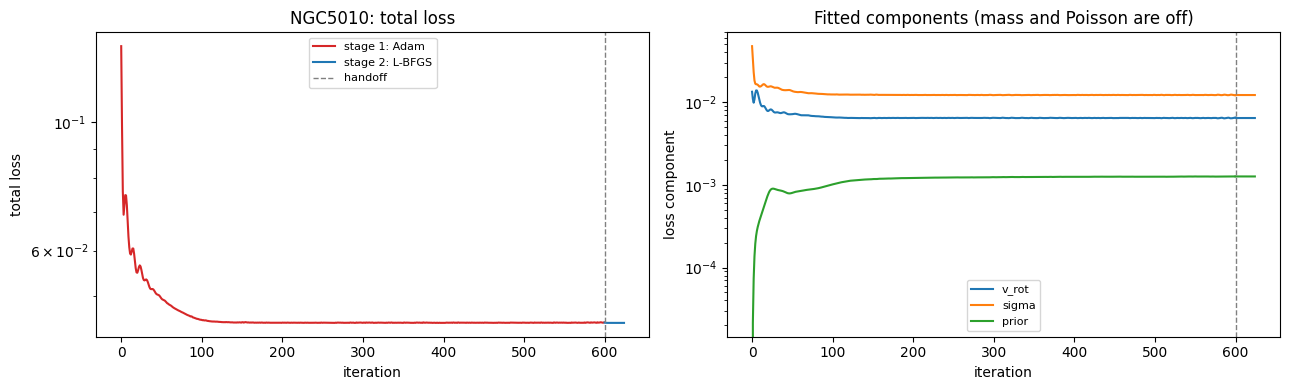

total loss:  Adam 0.045083  ->  +L-BFGS 0.045010
  v_rot      0.006495  ->  0.006439
  sigma      0.012167  ->  0.012214
  prior      0.001265  ->  0.001265


In [10]:
x_lb = np.arange(len(h_ad['loss']), len(h_ad['loss']) + len(h_lb['loss']))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(h_ad['loss'], color='tab:red', label='stage 1: Adam')
axes[0].plot(x_lb, h_lb['loss'], color='tab:blue', label='stage 2: L-BFGS')
axes[0].axvline(x_lb[0], color='gray', ls='--', lw=1, label='handoff')
axes[0].set_yscale('log'); axes[0].set_xlabel('iteration'); axes[0].set_ylabel('total loss')
axes[0].set_title(f'{NAME}: total loss'); axes[0].legend(fontsize=8)

for key, lab in [('vrot_loss', 'v_rot'), ('sigma_loss', 'sigma'), ('reg', 'prior')]:
    line, = axes[1].plot(h_ad[key], label=lab)
    axes[1].plot(x_lb, h_lb[key], color=line.get_color())
axes[1].axvline(x_lb[0], color='gray', ls='--', lw=1)
axes[1].set_yscale('log'); axes[1].set_xlabel('iteration'); axes[1].set_ylabel('loss component')
axes[1].set_title('Fitted components (mass and Poisson are off)'); axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

# Both stages are at one fixed bandwidth, so this comparison is like-for-like: it is a
# real improvement in fit, not a change in what is being measured.
print(f"total loss:  Adam {h_ad['loss'][-1]:.6f}  ->  +L-BFGS {h_lb['loss'][-1]:.6f}")
for key, lab in [('vrot_loss', 'v_rot'), ('sigma_loss', 'sigma'), ('reg', 'prior')]:
    print(f"  {lab:6s}     {h_ad[key][-1]:.6f}  ->  {h_lb[key][-1]:.6f}")
if result_lbfgs['n_projected']:
    print(f"\nbounds projection active on {result_lbfgs['n_projected']} iterations"
          f" -- check the AT BOUND flags in Section 7")


## 6. Maps and Residuals

Both models are rendered with far more tracers than the fit used (`render_maps_batched`, chunked to bound memory) at the bandwidth the fit ran at, so Monte-Carlo graininess does not masquerade as model error.


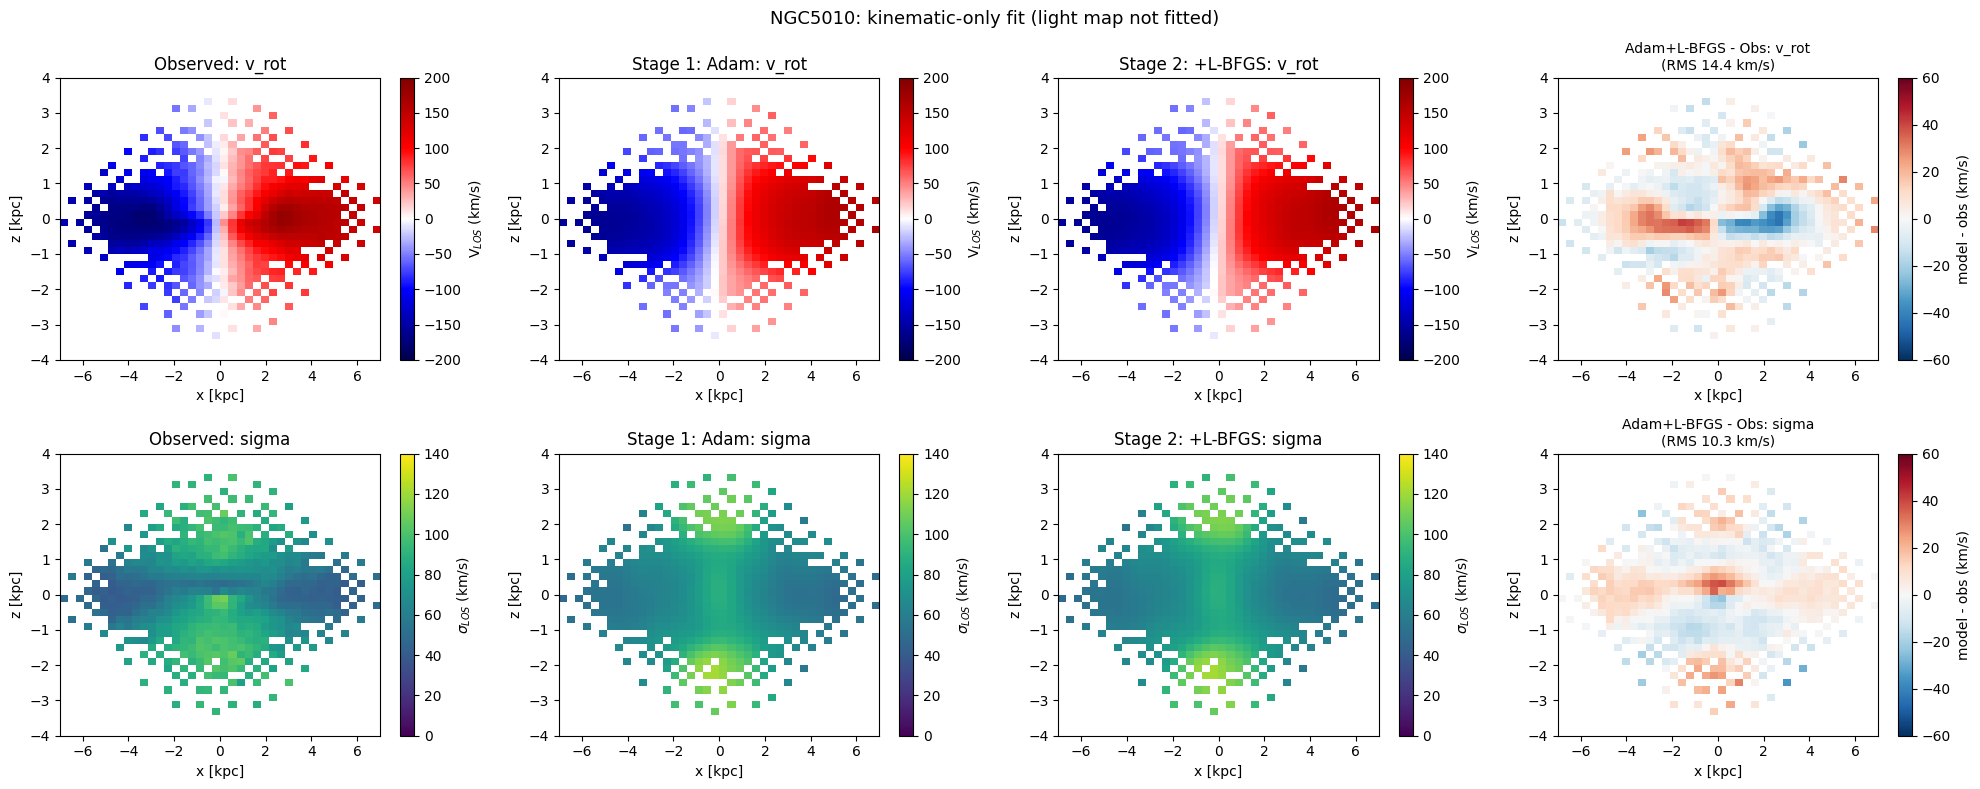

Residuals over the 558 cells with data:
  Adam        v_rot : RMS  14.46 km/s   median  +3.98   max|.|  44.78
  Adam        sigma : RMS  10.28 km/s   median  +0.93   max|.|  38.81
  Adam+L-BFGS v_rot : RMS  14.40 km/s   median  +3.82   max|.|  44.36
  Adam+L-BFGS sigma : RMS  10.32 km/s   median  +1.11   max|.|  39.05


In [11]:
render_kw = dict(N_disk=N_PARTICLES_RENDER, N_bulge=N_PARTICLES_RENDER,
                 grid_size=GRID_SIZE, extent_x=EXTENT_X, extent_z=EXTENT_Z,
                 prng_seed=SEED, soft_bin_h=OBS_BANDWIDTH,
                 spheroid_corotation=SPHEROID_COROTATION, chunk=15_000)

maps_adam = render_maps_batched(mapper, result_adam['pot_params'],
                                result_adam['disk_df_params'],
                                result_adam['bulge_df_params'], **render_kw)
maps_df = render_maps_batched(mapper, result_lbfgs['pot_params'],
                              result_lbfgs['disk_df_params'],
                              result_lbfgs['bulge_df_params'], **render_kw)

specs = [('v_rot', 'seismic', dict(vmin=-200, vmax=200), 'V$_{LOS}$ (km/s)'),
         ('sigma', 'viridis', dict(vmin=0, vmax=SIGMA_VMAX), '$\\sigma_{LOS}$ (km/s)')]

# 4 columns: Observed, Adam, Adam+L-BFGS, Residual of the final model
fig, axes = plt.subplots(2, 4, figsize=(20, 8))
for row, (key, cmap, kw, label) in enumerate(specs):
    for col, (t, arr) in enumerate([('Observed', obs_maps[key]),
                                    ('Stage 1: Adam', maps_adam[key]),
                                    ('Stage 2: +L-BFGS', maps_df[key])]):
        im = axes[row, col].imshow(masked(arr), origin='lower', extent=EXTENT,
                                   cmap=cmap, aspect='auto', **kw)
        axes[row, col].set_title(f'{t}: {key}')
        fig.colorbar(im, ax=axes[row, col], label=label)

    d = np.where(data_mask, np.array(maps_df[key]) - np.array(obs_maps[key]), np.nan)
    rms = float(np.sqrt(np.nanmean(d ** 2)))
    im = axes[row, 3].imshow(d, origin='lower', extent=EXTENT, cmap='RdBu_r',
                             vmin=-60, vmax=60, aspect='auto')
    axes[row, 3].set_title(f'Adam+L-BFGS - Obs: {key}\n(RMS {rms:.1f} km/s)', fontsize=10)
    fig.colorbar(im, ax=axes[row, 3], label='model - obs (km/s)')

for ax in axes.ravel():
    ax.set_xlabel('x [kpc]'); ax.set_ylabel('z [kpc]')
fig.suptitle(f'{NAME}: kinematic-only fit (light map not fitted)', fontsize=13)
plt.tight_layout(); plt.show()

print(f"Residuals over the {int(data_mask.sum())} cells with data:")
for tag, mp in [('Adam       ', maps_adam), ('Adam+L-BFGS', maps_df)]:
    for key in ('v_rot', 'sigma'):
        o = np.array(obs_maps[key])
        d = np.where(data_mask, np.array(mp[key]) - o, np.nan)
        print(f"  {tag} {key:6s}: RMS {np.sqrt(np.nanmean(d**2)):6.2f} km/s   "
              f"median {np.nanmedian(d):+6.2f}   max|.| {np.nanmax(np.abs(d)):6.2f}")


### Did the disk actually get more prominent, and for the right reason?

The map figure alone cannot answer that: a better-looking `V_LOS` map could come from a genuinely cooler, faster disk, or from the spheroid being re-weighted, or from the fit simply trading the `sigma` map away. The decomposition below separates them. It re-samples the fitted model, splits the tracers into their disk and spheroid halves (`sample_and_map_particles` returns them concatenated, disk first), and bins each separately, so the disk's own rotation and the spheroid's light share are measured rather than inferred.

Read it against the previous fit's numbers in the table above: midplane `sigma` of 82-85 km/s against an observed 60-62, and a disk-only `v_rot` of 148 km/s at x = 2.6 kpc against an observed 181.


spheroid share of the total tracer mass: 0.122

midplane (z ~ +0.10 kpc)
 x[kpc]  f_bulge    obs v  model v   disk v  obs sig  mod sig
  -5.78    0.038   -156.4   -155.2   -159.2     46.6     48.4
  -4.72    0.043   -168.0   -158.4   -163.1     39.7     53.2
  -3.67    0.037   -176.6   -159.6   -163.5     42.8     53.7
  -2.62    0.041   -168.3   -134.6   -138.4     49.9     65.5
  -1.57    0.040   -121.7   -106.8   -109.5     58.3     64.9
  -0.52    0.041    -51.4    -52.3    -53.1     61.6     83.8
   0.53    0.044     47.1     46.4     46.2     60.0     83.2
   1.58    0.045    118.7    119.4    122.0     61.9     66.8
   2.63    0.033    181.4    142.6    145.3     49.2     58.1
   3.68    0.034    165.5    154.7    158.3     46.3     56.3
   4.73    0.030    157.1    164.2    167.8     44.3     50.6
   5.78    0.036    148.2    162.7    167.1     45.2     50.4


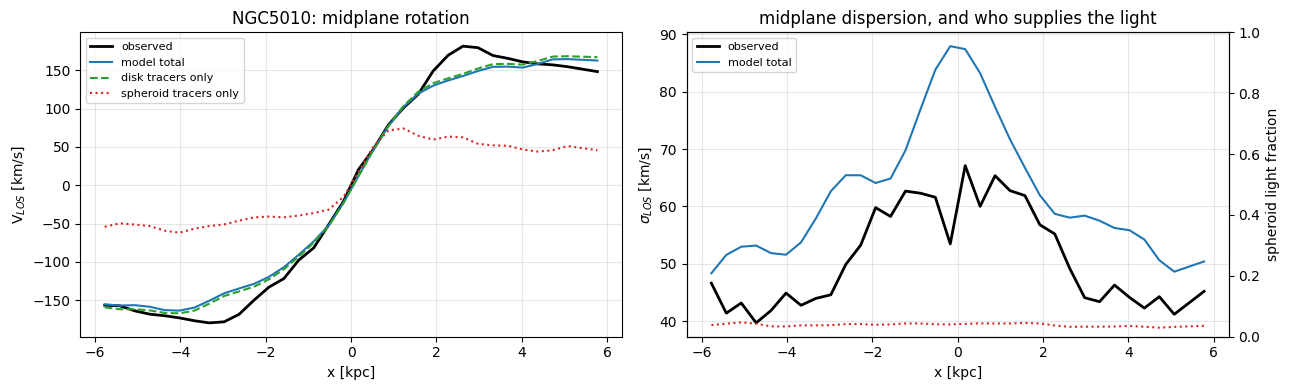


midplane, model minus observed:
  |v_rot| deficit (mean over the row): +10.48 km/s
  sigma excess    (mean over the row): +11.51 km/s


In [12]:
from phoenix.optimization.observables import sample_and_map_particles, bin_maps

N_DIAG = 20_000
_x, _y, _z, _vx, _vy, _vz, _w = sample_and_map_particles(
    mapper, result_lbfgs['pot_params'], result_lbfgs['disk_df_params'],
    result_lbfgs['bulge_df_params'], N_disk=N_DIAG, N_bulge=N_DIAG,
    prng_seed=SEED, spheroid_corotation=SPHEROID_COROTATION)

_bk = dict(grid_size=GRID_SIZE, extent_x=EXTENT_X, extent_z=EXTENT_Z,
           soft_bin_h=OBS_BANDWIDTH)
m_all = bin_maps(_x, _z, _vy, _w, **_bk)
m_dsk = bin_maps(_x[:N_DIAG], _z[:N_DIAG], _vy[:N_DIAG], _w[:N_DIAG], **_bk)
m_bul = bin_maps(_x[N_DIAG:], _z[N_DIAG:], _vy[N_DIAG:], _w[N_DIAG:], **_bk)

md_, mb_ = np.array(m_dsk['mass']), np.array(m_bul['mass'])
f_bulge = mb_ / np.maximum(md_ + mb_, 1e-30)
xc = np.linspace(-EXTENT_X + EXTENT_X / GRID_SIZE, EXTENT_X - EXTENT_X / GRID_SIZE, GRID_SIZE)
zc = np.linspace(-EXTENT_Z + EXTENT_Z / GRID_SIZE, EXTENT_Z - EXTENT_Z / GRID_SIZE, GRID_SIZE)
iz = int(np.argmin(np.abs(zc)))

print(f"spheroid share of the total tracer mass: {float(_w[N_DIAG:].sum() / _w.sum()):.3f}")
print(f"\nmidplane (z ~ {zc[iz]:+.2f} kpc)")
print(f"{'x[kpc]':>7s} {'f_bulge':>8s} {'obs v':>8s} {'model v':>8s} {'disk v':>8s}"
      f" {'obs sig':>8s} {'mod sig':>8s}")
for i in range(0, GRID_SIZE, 3):
    if not data_mask[iz, i]:
        continue
    print(f"{xc[i]:7.2f} {f_bulge[iz, i]:8.3f} {np.array(obs_maps['v_rot'])[iz, i]:8.1f}"
          f" {np.array(m_all['v_rot'])[iz, i]:8.1f} {np.array(m_dsk['v_rot'])[iz, i]:8.1f}"
          f" {np.array(obs_maps['sigma'])[iz, i]:8.1f} {np.array(m_all['sigma'])[iz, i]:8.1f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
row = data_mask[iz]
axes[0].plot(xc[row], np.array(obs_maps['v_rot'])[iz][row], 'k-', lw=2, label='observed')
axes[0].plot(xc[row], np.array(m_all['v_rot'])[iz][row], color='tab:blue', label='model total')
axes[0].plot(xc[row], np.array(m_dsk['v_rot'])[iz][row], color='tab:green', ls='--',
             label='disk tracers only')
axes[0].plot(xc[row], np.array(m_bul['v_rot'])[iz][row], color='tab:red', ls=':',
             label='spheroid tracers only')
axes[0].set_xlabel('x [kpc]'); axes[0].set_ylabel('V$_{LOS}$ [km/s]')
axes[0].set_title(f'{NAME}: midplane rotation'); axes[0].legend(fontsize=8); axes[0].grid(alpha=.3)

axes[1].plot(xc[row], np.array(obs_maps['sigma'])[iz][row], 'k-', lw=2, label='observed')
axes[1].plot(xc[row], np.array(m_all['sigma'])[iz][row], color='tab:blue', label='model total')
ax2 = axes[1].twinx()
ax2.plot(xc[row], f_bulge[iz][row], color='tab:red', ls=':', label='spheroid light fraction')
ax2.set_ylabel('spheroid light fraction'); ax2.set_ylim(0, 1)
axes[1].set_xlabel('x [kpc]'); axes[1].set_ylabel('$\\sigma_{LOS}$ [km/s]')
axes[1].set_title('midplane dispersion, and who supplies the light')
axes[1].legend(fontsize=8, loc='upper left'); axes[1].grid(alpha=.3)
plt.tight_layout(); plt.show()

# The asymmetric-drift signature: a hot disk rotates below the circular speed. If the
# disk is still too hot, the sigma excess and the v_rot deficit persist together.
_sel = data_mask[iz]
_dv = np.array(m_all['v_rot'])[iz][_sel] - np.array(obs_maps['v_rot'])[iz][_sel]
_ds = np.array(m_all['sigma'])[iz][_sel] - np.array(obs_maps['sigma'])[iz][_sel]
print(f"\nmidplane, model minus observed:")
print(f"  |v_rot| deficit (mean over the row): "
      f"{np.mean(np.abs(np.array(obs_maps['v_rot'])[iz][_sel])) - np.mean(np.abs(np.array(m_all['v_rot'])[iz][_sel])):+6.2f} km/s")
print(f"  sigma excess    (mean over the row): {np.mean(_ds):+6.2f} km/s")


## 7. Fitted Parameters

No ground truth exists, so these are answers rather than scores. The diagnostics are: **~unmoved** — the value barely left the initial guess, i.e. the Tikhonov prior is holding it rather than the data; **frozen** — the loss gradient was numerically zero at the initial guess (Section 2); bound proximity; and **MOVED BY POLISH** — L-BFGS shifted the parameter by more than 20% from Adam's answer, which means the Adam stage had not converged in that direction and the 600-step number should not be quoted for it. That flag is a statement about the optimizer, not about the data: a parameter can be well converged and still be poorly constrained.

Bound proximity is measured in **log space**, the space the optimizer works in; a linear test is meaningless when a bound range spans orders of magnitude.


In [13]:
def flat_params(res):
    return {**res['pot_params'], **res['disk_df_params'], **res['bulge_df_params']}

pf, pa = flat_params(result_lbfgs), flat_params(result_adam)
init_all = {**init_pot, **init_disk, **init_bulge}
bounds_all = {**param_bounds['pot'], **param_bounds['disk'], **param_bounds['bulge']}


def bound_flag(v, lo, hi, frac=0.02):
    if lo > 0 and v > 0 and hi > lo:
        f = (math.log(v) - math.log(lo)) / (math.log(hi) - math.log(lo))
    elif hi > lo:
        f = (v - lo) / (hi - lo)
    else:
        return ''
    if f <= frac:
        return 'AT LOWER BOUND'
    if f >= 1.0 - frac:
        return 'AT UPPER BOUND'
    return ''


print(f"{'parameter':16s} {'init':>11s} {'adam':>11s} {'+lbfgs':>11s} "
      f"{'fit/init':>9s} {'polish':>7s}  notes")
for k in init_all:
    v, a = float(pf[k]), float(pa[k])
    lo, hi = bounds_all[k]
    notes = []
    if k in FROZEN:
        notes.append('frozen (unconstrained)')
    bf = bound_flag(v, lo, hi)
    if bf:
        notes.append(bf)
    ratio = (v / init_all[k]) if init_all[k] != 0 else float('nan')
    polish = (v / a) if a != 0 else float('nan')
    if k not in FROZEN and abs(polish - 1.0) > 0.20:
        notes.append('MOVED BY POLISH -> Adam had not converged here')
    if k not in FROZEN and abs(ratio - 1.0) < 0.05 and REG_WEIGHT > 0:
        notes.append('~unmoved: set by the prior, not the data')
    print(f"{k:16s} {init_all[k]:11.4g} {a:11.4g} {v:11.4g} "
          f"{ratio:9.2f} {polish:7.2f}  {', '.join(notes)}")

moved = [k for k in init_all if k not in FROZEN
         and abs(float(pf[k]) / float(pa[k]) - 1.0) > 0.20]
print(f"\n{len(moved)}/{len([k for k in init_all if k not in FROZEN])} free parameters "
      f"moved >20% during the polish" + (f": {', '.join(moved)}" if moved else ''))


parameter               init        adam      +lbfgs  fit/init  polish  notes
M_halo                 8e+11    1.32e+12   1.322e+12      1.65    1.00  
a_halo                    15       30.72       30.65      2.04    1.00  
M_disk                 4e+10   4.763e+10    4.78e+10      1.20    1.00  
a_disk                     2       2.007           2      1.00    1.00  ~unmoved: set by the prior, not the data
b_disk                   0.2      0.2613      0.2612      1.31    1.00  
M_bulge                5e+09    6.64e+09   6.654e+09      1.33    1.00  
a_bulge                  0.5      0.7009         0.7      1.40    1.00  
R0                         4       4.256       4.256      1.06    1.00  
Rd                       1.5      0.7317      0.7294      0.49    1.00  
Sigma0                  1000        1000        1000      1.00    1.00  frozen (unconstrained)
RsigR                      5       7.196       7.195      1.44    1.00  
RsigZ                      5        1.93       1.934     

## 8. Summary and Caveats

**Fitted:** the `V_LOS` and `sigma_LOS` maps of NGC 5010, `v_rot` up-weighted 3:2 over `sigma`, with a co-rotating spheroid (`spheroid_corotation=1.0`) and a well-centred field, at a **constant** smoothing bandwidth of 0.4 kpc, by **Adam followed by an L-BFGS polish** on the identical objective.

**Not fitted:** the light map (`w_mass=0` — MUSE FLUX is light with a fiducial normalization) and self-consistency (`w_poisson=0` — a real galaxy cannot be pre-made self-consistent, so the term would impose a prior that cannot be validated against this galaxy first).

**Caveats, all of which apply to any number above:**

- **No ground truth.** A good map fit does not make the parameters right. Trust the `frozen` / `~unmoved` flags over the fitted values.
- **A single optimization path.** The polish is a refinement of Adam's path, not an independent one, so agreement between the two stages is not evidence the answer is right — it only means Adam had converged. A parameter that both stages agree on may still be poorly constrained by the data.
- **A better-converged fit is not a better-determined one.** L-BFGS finds the minimum of this objective more precisely; it adds no information. Where the kinematics are degenerate the extra precision just locates a more exact point along a flat direction, and the Tikhonov prior — not the data — decides where along it. Read the `MOVED BY POLISH` flags as a statement about how converged Section 3 was, and the `~unmoved` and `AT BOUND` flags as the statement about what the data actually constrains.
- **Float32.** Everything runs in single precision (`params_to_log` casts explicitly), so gradients carry ~1e-7 relative error. A quasi-Newton method converges quadratically only until it reaches that floor, after which the line search fails; a `line search stalled` stop reason is that precision limit, not a bug.
- **Light is not mass.** `M_disk`/`M_bulge` absorb the constant-M/L assumption; only the velocities carry an absolute physical scale.
- **Self-consistency is not enforced**, so the fitted model is not guaranteed to be a dynamically valid galaxy.
- **Axisymmetric model.** NGC 5010's coverage is symmetric (unlike NGC 3630's), which is a better match to the model's assumptions — but real galaxies still have non-axisymmetric structure the model cannot represent.
- **Reduced tracer count:** 20,000 tracers and 600 steps here for runtime, against 35,000 / 700 in `fit_geckos.py`, so the Monte-Carlo noise floor is slightly higher than necessary.
- **Distance and M\*** are catalogue values; an error there propagates directly into the inferred masses and scale lengths.

**On the two configuration changes.** `REG_WEIGHT = 0.01` and `LOSS_WEIGHTS = (0, 3, 2, 0)` were chosen after measuring the previous fit's residuals (Section 2), not by scanning for the best-looking map — but they are still two knobs turned once, on one galaxy, with no held-out data. Two consequences to carry into any use of these numbers:

- The `sigma` map is now deliberately the lower-priority observable. A `sigma` residual that got worse is the expected cost of the re-weighting, not a new defect, and quoting the improved `v_rot` residual without it is not an honest summary of the fit.
- The weaker prior means the flat directions are held by very little. The `AT BOUND` flags in Section 7 and the drift warning in Section 2's probe cell are the checks that matter; a parameter that landed on a bound under `REG_WEIGHT = 0.01` is reporting the bound, not the galaxy.
